# Notebook 7.1: Building Performance Metrics from Scratch



## Financial Trading with Python, 2nd Edition

---

Every strategy produces numbers: returns, volatility, drawdowns. But a number without context is meaningless. A 15% annual return sounds impressive until you learn the strategy had a 40% drawdown to get there. A Sharpe ratio of 1.2 sounds strong until you realize it was calculated with the wrong annualization factor.

This notebook builds every major performance metric from scratch so you understand exactly what each one measures, how it is calculated, and why it matters. We use a simple 50/200-day SMA crossover strategy on SPY as the teaching vehicle. The strategy is deliberately basic: the goal is to learn the metrics, not the strategy.

This notebook covers:

- Setting up the teaching strategy with a vectorized weight-based backtest
- Return metrics: total return and annualized return (CAGR)
- Risk metrics: volatility, downside deviation, maximum drawdown, and drawdown duration
- Risk-adjusted metrics: Sharpe ratio, Sortino ratio, Calmar ratio, and information ratio
- Trading metrics: win rate, profit factor, and average win/loss ratio
- A reusable summary function you will carry forward through the rest of the book

## Section 1: Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

### 1.1 Loading Data

We load the same case study price data used throughout the book. For this notebook we only need SPY (our trading asset) and BIL (our cash proxy when the strategy is out of the market).

In [4]:
# --- Load case study data ---
df_prices = pd.read_parquet('case_study_prices.parquet')

# We only need SPY and BIL for the crossover strategy
df_prices = df_prices[['SPY', 'BIL']].copy()
df_returns = df_prices.pct_change().dropna()

print(f"Data loaded: {df_prices.shape[0]} trading days")
print(f"Date range: {df_prices.index[0].strftime('%Y-%m-%d')} to "
      f"{df_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"\nColumns: {list(df_prices.columns)}")
print(f"\nFirst few rows:")
print(df_prices.head())

Data loaded: 3771 trading days
Date range: 2011-01-04 to 2025-12-31

Columns: ['SPY', 'BIL']

First few rows:
               SPY     BIL
Date                      
2011-01-04 97.1394 74.9744
2011-01-05 97.6442 74.9744
2011-01-06 97.4530 74.9744
2011-01-07 97.2618 74.9580
2011-01-10 97.1394 74.9744


We have 3,771 trading days of SPY and BIL prices from January 2011 through December 2025. This is the same dataset and date range used in Notebook 6.4, which will make comparisons straightforward when we revisit the filter results in the chapter text.

SPY is the S&P 500 ETF that serves as both our trading asset and our benchmark. BIL is the SPDR Bloomberg 1-3 Month T-Bill ETF, which we use as a cash proxy. When the crossover signal says "out of the market," the portfolio holds BIL rather than sitting in literal cash, so every dollar is always allocated somewhere.

## Section 2: Building the Teaching Strategy

### 2.1 Generating the Crossover Signal

The 50/200-day SMA crossover is one of the oldest and most widely recognized trading signals. The logic is simple: when the 50-day SMA crosses above the 200-day SMA, the short-term trend is accelerating relative to the long-term trend, and we go long SPY. When it crosses below, momentum is fading, and we move to BIL.

We are not here to evaluate whether this is a good strategy. It is the teaching vehicle for learning performance metrics. We use the same vectorized weight-based return calculation from Notebook 6.4: daily portfolio returns are the weighted average of each asset's daily return, using the previous day's weights to avoid lookahead bias. This is a simplified backtest that does not account for transaction costs, slippage, or rebalancing mechanics. Proper backtesting comes in Chapter 8.

In [5]:
# --- Calculate moving averages ---
sma_50 = df_prices['SPY'].rolling(window=50).mean()
sma_200 = df_prices['SPY'].rolling(window=200).mean()

# --- Generate signal ---
# Long SPY when SMA50 > SMA200, hold BIL otherwise
signal = (sma_50 > sma_200).astype(int)

# --- Build daily weights ---
df_weights = pd.DataFrame(index=df_prices.index)
df_weights['SPY'] = signal       # 1.0 when long, 0.0 when out
df_weights['BIL'] = 1 - signal   # 0.0 when long, 1.0 when in cash

# Drop the warmup period (first 200 days needed for SMA200)
df_weights = df_weights.dropna()

# --- Calculate portfolio returns using lagged weights ---
# Use yesterday's weights with today's returns (no lookahead)
common_idx = df_weights.index.intersection(df_returns.index)
w_lagged = df_weights.loc[common_idx].shift(1).dropna()
r_aligned = df_returns.loc[w_lagged.index]

strategy_returns = (w_lagged * r_aligned).sum(axis=1)
strategy_returns.name = 'SMA_Crossover'

# SPY buy-and-hold benchmark for comparison
benchmark_returns = r_aligned['SPY'].copy()
benchmark_returns.name = 'SPY_Buy_Hold'

print(f"Strategy period: {strategy_returns.index[0].strftime('%Y-%m-%d')} to "
      f"{strategy_returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(strategy_returns)}")
print(f"\nDays long SPY: {(w_lagged['SPY'] == 1).sum()} "
      f"({(w_lagged['SPY'] == 1).mean():.1%})")
print(f"Days in BIL:   {(w_lagged['SPY'] == 0).sum()} "
      f"({(w_lagged['SPY'] == 0).mean():.1%})")

Strategy period: 2011-01-06 to 2025-12-31
Trading days: 3769

Days long SPY: 2972 (78.9%)
Days in BIL:   797 (21.1%)


The strategy is long SPY about 79% of the time and in BIL for the remaining 21%. This makes sense for a trend-following signal on an asset that has been in a structural bull market for most of the sample period. The 50/200 crossover only moves to cash during sustained downtrends, which have been relatively brief episodes in this 15-year window.

Note the strategy period starts on 2011-01-06, not 2011-01-04. We lose the first 200 trading days to the SMA warmup period, and one additional day to the weight lag (we use yesterday's weights with today's returns to avoid lookahead bias). This is the same convention we used in Notebook 6.4.

Now let us visualize the equity curves to see how the strategy behaves before we start calculating metrics.

### 2.2 Equity Curves

The equity curve shows the growth of $1 invested at the start of the strategy period. It is the most intuitive way to compare two strategies, but it can also be misleading. A strategy that looks "smoother" on an equity curve might still have painful drawdowns that are hard to see at this scale. That is why we need formal metrics, which we will build in the sections that follow.

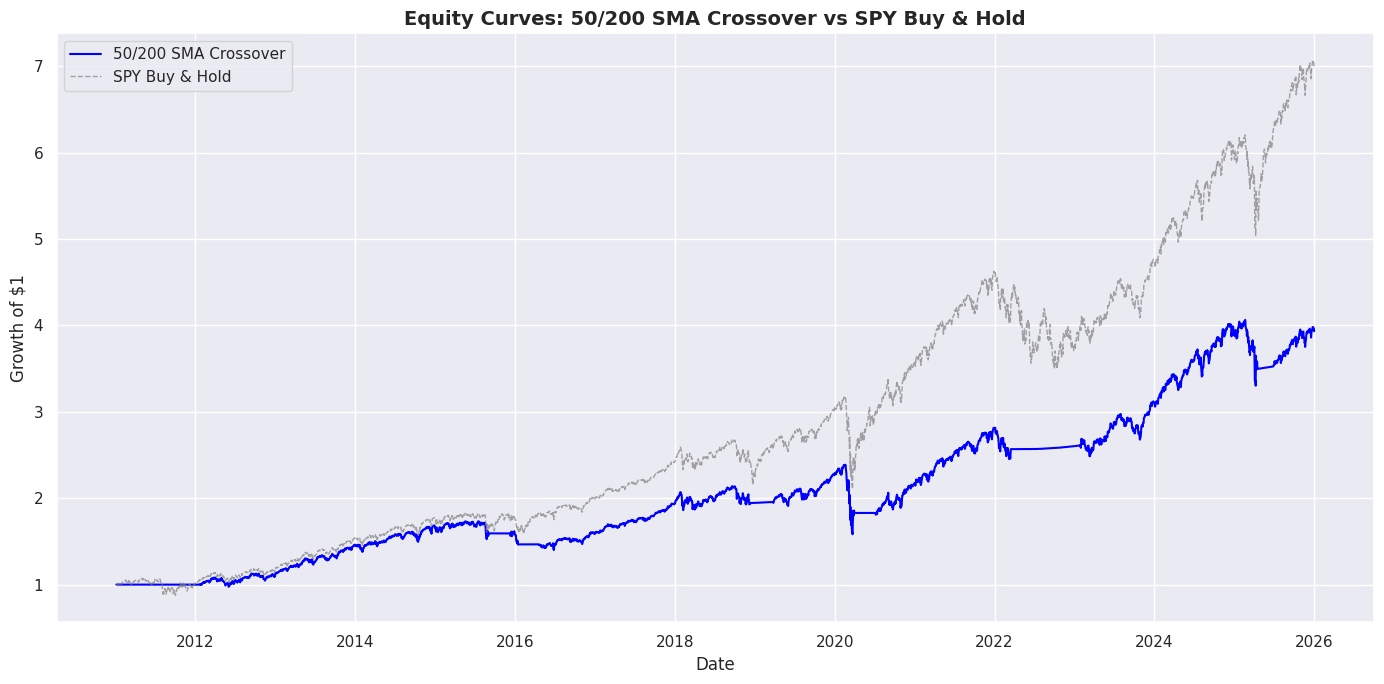

In [6]:
# --- Calculate cumulative returns (growth of $1) ---
# (1 + r) compounds each day's return into a running total.
# Starting from 1.0 means the y-axis reads as a multiplier:
# 2.0 = doubled your money, 3.0 = tripled, etc.
strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

# --- Plot equity curves ---
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(strategy_cumulative, color='blue', linewidth=1.5,
        label='50/200 SMA Crossover')
ax.plot(benchmark_cumulative, color='gray', linewidth=1,
        linestyle='--', alpha=0.7, label='SPY Buy & Hold')

ax.set_title('Equity Curves: 50/200 SMA Crossover vs SPY Buy & Hold',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

Two things jump out immediately.

First, SPY buy-and-hold wins on total return by a wide margin. A dollar invested in SPY grew to roughly $7 over this period, while the crossover strategy reached about $4. This is expected: the strategy sits in BIL (earning near-zero) for about 21% of trading days, and those days include stretches of the post-2020 bull market where SPY rallied sharply. Every day out of the market during a rally is a day of missed gains that compounds forward.

Second, the crossover strategy is visibly smoother. Look at the COVID crash in early 2020: SPY dropped sharply while the crossover strategy's decline was shallower. The same pattern appears in the 2022 drawdown. The strategy avoided some of the worst pain by moving to cash when the 50-day SMA crossed below the 200-day SMA.

This is the classic trend-following tradeoff: you give up upside to avoid drawdowns. Whether that tradeoff is worthwhile depends on which metrics you prioritize. Total return says SPY wins. But total return does not tell you how much pain you endured to get there. The metrics we build in the next sections will give us a more complete picture.

## Section 3: Return Metrics

The most basic question about any strategy is: how much money did it make? But even this simple question has more than one answer. Total return tells you the end result. Annualized return (CAGR) normalizes that result to a per-year figure so you can compare strategies that ran for different lengths of time. We build both from scratch.

In [7]:
# --- Total Return ---
# Total return is the cumulative product of (1 + daily return) minus 1.
# It answers: if I invested $1 at the start, how much did I gain or lose?
strategy_total_return = (1 + strategy_returns).prod() - 1
benchmark_total_return = (1 + benchmark_returns).prod() - 1

print("Total Return")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_total_return:.2%}")
print(f"SPY Buy & Hold:        {benchmark_total_return:.2%}")

# --- Annualized Return (CAGR) ---
# Total return is useful but misleading for comparison because it depends
# on how long the strategy ran. A 100% total return over 5 years is very
# different from 100% over 15 years.
#
# CAGR (Compound Annual Growth Rate) solves this by converting total
# return into a constant annual rate that would produce the same result
# if compounded over the same number of years.
#
# Formula: CAGR = (1 + total_return) ^ (252 / total_trading_days) - 1
# We use 252 trading days per year as the annualization factor.

total_days = len(strategy_returns)
strategy_cagr = (1 + strategy_total_return) ** (252 / total_days) - 1
benchmark_cagr = (1 + benchmark_total_return) ** (252 / total_days) - 1

print(f"\nAnnualized Return (CAGR)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_cagr:.2%}")
print(f"SPY Buy & Hold:        {benchmark_cagr:.2%}")

Total Return
50/200 SMA Crossover:  293.14%
SPY Buy & Hold:        598.37%

Annualized Return (CAGR)
50/200 SMA Crossover:  9.59%
SPY Buy & Hold:        13.88%


SPY buy-and-hold returned 598% over the period, versus 293% for the crossover strategy. Annualized, that is 13.88% for SPY versus 9.59% for the crossover. The crossover strategy gave up over 4% per year in return by sitting in BIL during its cash periods.

If total return and CAGR were the only metrics that mattered, this would be an easy verdict: buy SPY and go to the beach. And for many investors, that is the right answer. You cannot feed your family with a Sharpe ratio. Returns pay the bills.

But total return hides the experience of earning those returns. SPY's 598% gain included a stretch in early 2020 where it lost roughly a third of its value in weeks. It included a grinding drawdown through most of 2022. The crossover strategy earned less, but the question we have not answered yet is: how much less pain did it take to get there? That is what risk metrics tell us.

## Section 4: Risk Metrics

Return metrics tell you how much you made. Risk metrics tell you how much you suffered along the way. In practice, risk is what gets people fired and what makes them abandon strategies at the worst possible time. A strategy that drops 40% will cause most people to shut it down, even if it would have recovered and delivered strong long-term returns. Understanding and measuring risk is not optional.

### 4.1 Annualized Volatility

Volatility is the most common measure of risk in finance. It is the annualized standard deviation of daily returns. Higher volatility means the strategy's daily returns are more spread out, which means bigger up days but also bigger down days.

Volatility treats upside and downside equally. A strategy that occasionally jumps 5% in a day gets the same volatility penalty as one that occasionally drops 5%. This is a well-known limitation that we will address with downside deviation in the next subsection.

In [8]:
# --- Annualized Volatility ---
# Step 1: Calculate the standard deviation of daily returns.
#         This gives us daily volatility.
# Step 2: Multiply by sqrt(252) to annualize.
#         This scaling assumes daily returns are roughly independent,
#         which is a simplification but the standard industry convention.

strategy_vol = strategy_returns.std() * np.sqrt(252)
benchmark_vol = benchmark_returns.std() * np.sqrt(252)

print("Annualized Volatility")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_vol:.2%}")
print(f"SPY Buy & Hold:        {benchmark_vol:.2%}")

Annualized Volatility
50/200 SMA Crossover:  13.81%
SPY Buy & Hold:        17.17%


The crossover strategy has an annualized volatility of 13.81%, compared to 17.17% for SPY buy-and-hold. That is about 20% less volatile. The reduction comes from the cash periods: when the strategy is in BIL, it is essentially flat while SPY swings up and down. This dampens the overall dispersion of daily returns.

Note that the strategy's volatility is not zero during cash periods. BIL has a small amount of daily price variation, and the transitions in and out of SPY create their own return patterns. But the effect is clear: spending 21% of the time in near-zero-volatility BIL pulls the overall volatility down meaningfully.

The limitation here is that volatility penalizes big up days just as much as big down days. If our strategy occasionally catches a sharp rally, that counts as risk under this measure. Most practitioners care more about the downside, which leads us to downside deviation.

### 4.2 Downside Deviation

Downside deviation measures only the volatility of negative returns. It answers a more targeted question than standard volatility: how bad are the bad days? This is closer to what most investors actually mean when they say "risk." Nobody complains about upside volatility.

The calculation is the same as standard deviation, but we only include returns below a target threshold (typically zero). Positive returns are excluded entirely. This means a strategy that has the same volatility as another but concentrates more of its variation on the upside will have a lower downside deviation.

In [9]:
# --- Downside Deviation ---
# Step 1: Isolate only the negative daily returns.
#         We set the threshold at zero: any day with a positive return
#         is replaced with zero so it does not contribute to the calculation.
# Step 2: Calculate the standard deviation of these downside-only values.
# Step 3: Annualize by multiplying by sqrt(252), same as standard volatility.
#
# np.minimum(returns, 0) replaces all positive returns with 0,
# keeping negative returns as-is. The standard deviation of this
# series captures only the dispersion of losses.

strategy_downside = np.sqrt(np.mean(np.minimum(strategy_returns, 0) ** 2)) * np.sqrt(252)
benchmark_downside = np.sqrt(np.mean(np.minimum(benchmark_returns, 0) ** 2)) * np.sqrt(252)

print("Annualized Downside Deviation")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_downside:.2%}")
print(f"SPY Buy & Hold:        {benchmark_downside:.2%}")

Annualized Downside Deviation
50/200 SMA Crossover:  9.95%
SPY Buy & Hold:        12.20%


The crossover strategy's downside deviation is 9.95% versus 12.20% for SPY. The gap between the two (about 18% lower) is similar to what we saw with standard volatility, which tells us the strategy is not just less volatile overall but specifically less volatile on the downside.

Compare the two risk measures side by side. SPY's standard volatility is 17.17% but its downside deviation is only 12.20%. The difference (about 5 percentage points) represents the upside volatility that standard deviation counts as "risk" but that no investor actually worries about. Downside deviation strips that out and gives a cleaner picture of the pain.

We will use downside deviation again when we calculate the Sortino ratio in Section 5. The Sortino ratio is the return-per-unit-of-downside-risk equivalent of the Sharpe ratio, and it uses downside deviation as its denominator instead of standard volatility.

### 4.3 Maximum Drawdown

Maximum drawdown is the single most important risk metric for practitioners. It answers a brutal question: what was the worst peak-to-trough decline your strategy experienced? If your strategy had a maximum drawdown of -30%, that means at some point you were sitting at your desk watching 30% of your portfolio value disappear.

Drawdown is measured relative to the running peak, not relative to the starting value. A strategy could be up 200% and then drop 30% from that peak. The total return is still strongly positive, but the experience of losing 30% of what you had is real. Maximum drawdown captures that experience.

We calculate the full drawdown series (the percentage below the running peak at every point in time) and then extract the worst value. We also plot it, because the shape of the drawdown curve tells you things the single number cannot: how often drawdowns occur, how deep they go, and how long they take to recover.

Maximum Drawdown
50/200 SMA Crossover:  -33.72%
SPY Buy & Hold:        -33.72%


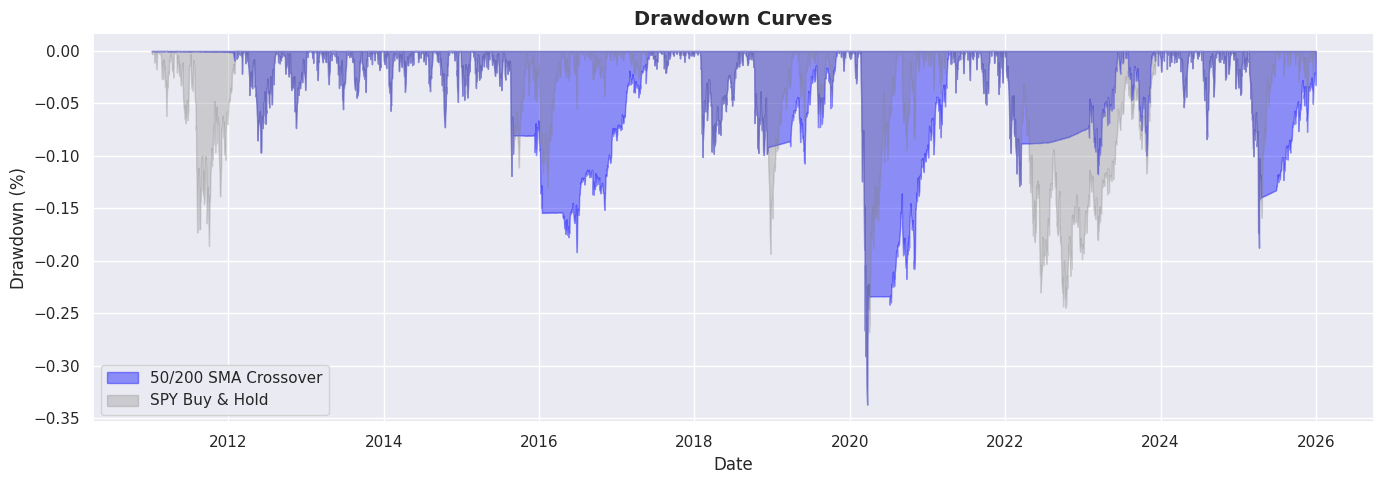

In [10]:
# --- Maximum Drawdown ---
# Step 1: Build the cumulative return series (growth of $1).
# Step 2: Calculate the running maximum at each point in time.
#         This is the highest value the portfolio has reached so far.
# Step 3: Drawdown = (current value - running max) / running max
#         This gives the percentage decline from the peak at every point.
#         When the portfolio is at a new high, drawdown is 0.
#         When it is below its peak, drawdown is negative.
# Step 4: Maximum drawdown is simply the minimum of this series.

strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

# Running peak: the highest cumulative value seen up to each date
strategy_running_max = strategy_cumulative.cummax()
benchmark_running_max = benchmark_cumulative.cummax()

# Drawdown series: how far below the peak at each point
strategy_drawdown = (strategy_cumulative - strategy_running_max) / strategy_running_max
benchmark_drawdown = (benchmark_cumulative - benchmark_running_max) / benchmark_running_max

# Maximum drawdown: the deepest trough in the entire series
strategy_max_dd = strategy_drawdown.min()
benchmark_max_dd = benchmark_drawdown.min()

print("Maximum Drawdown")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_max_dd:.2%}")
print(f"SPY Buy & Hold:        {benchmark_max_dd:.2%}")

# --- Plot drawdown curves ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(strategy_drawdown.index, strategy_drawdown,
                color='blue', alpha=0.4, label='50/200 SMA Crossover')
ax.fill_between(benchmark_drawdown.index, benchmark_drawdown,
                color='gray', alpha=0.3, label='SPY Buy & Hold')

ax.set_title('Drawdown Curves', fontsize=14, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()

Surprise: both strategies have the exact same maximum drawdown of -33.72%. The crossover strategy, despite being visibly smoother on the equity curve, experienced the same worst-case pain as SPY buy-and-hold.

The culprit is the COVID crash in early 2020. Look at the drawdown chart: the gray (SPY) and blue (crossover) areas plunge to the same depth at the same time. The crash happened so fast that by the time the 50-day SMA crossed below the 200-day SMA, the damage was already done. The crossover signal is inherently slow. It needs a sustained decline before the short-term average crosses below the long-term average, and COVID did not wait around for moving averages to catch up.

This is exactly the kind of insight that single-number metrics reveal. The equity curve made the crossover strategy look safer. The maximum drawdown tells you it was not safer when it mattered most. If you had pitched this strategy to a portfolio manager and said "it reduces risk," they would look at this number and say it did not reduce the risk they care about.

File this away for your next cocktail party: the 50/200 SMA crossover, one of the most famous trading signals in existence, delivered no drawdown protection during the fastest crash in modern market history. If that does not convince you to measure before you trust, nothing will.

Now let us look at how long those drawdowns lasted.

### 4.4 Maximum Drawdown Duration

Maximum drawdown tells you how deep the hole was. Maximum drawdown duration tells you how long you were stuck in it. A 20% drawdown that recovers in two months is a very different experience from a 20% drawdown that takes three years to recover. Duration measures the longest period between a portfolio peak and the next time it reaches a new high.

In [11]:
# --- Maximum Drawdown Duration ---
# Duration is the number of trading days between a peak and the next
# time the portfolio reaches or exceeds that peak.
#
# Logic:
#   - When drawdown == 0, the portfolio is at a new high.
#     Reset the counter.
#   - When drawdown < 0, the portfolio is below its peak.
#     Increment the counter.
#   - The maximum counter value is the longest underwater period.

def max_drawdown_duration(drawdown_series):
    """
    Calculate the maximum drawdown duration in trading days.

    Parameters:
    -----------
    drawdown_series : pd.Series
        The drawdown at each point in time (0 at peaks, negative below peaks)

    Returns:
    --------
    int : longest number of consecutive trading days spent below a prior peak
    """
    duration = 0          # current streak of days below the peak
    max_duration = 0      # longest streak seen so far

    for dd in drawdown_series:
        if dd < 0:
            # Still underwater — add another day
            duration += 1
            max_duration = max(max_duration, duration)
        else:
            # New peak reached — reset the counter
            duration = 0

    return max_duration

strategy_max_dd_dur = max_drawdown_duration(strategy_drawdown)
benchmark_max_dd_dur = max_drawdown_duration(benchmark_drawdown)

print("Maximum Drawdown Duration (trading days)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_max_dd_dur} days "
      f"(~{strategy_max_dd_dur / 252:.1f} years)")
print(f"SPY Buy & Hold:        {benchmark_max_dd_dur} days "
      f"(~{benchmark_max_dd_dur / 252:.1f} years)")

Maximum Drawdown Duration (trading days)
50/200 SMA Crossover:  470 days (~1.9 years)
SPY Buy & Hold:        488 days (~1.9 years)


The maximum drawdown durations are nearly identical: 470 trading days for the crossover versus 488 for SPY, both roughly 1.9 years. Like the maximum drawdown depth, this is driven by the COVID crash and the time it took both strategies to recover to their prior peaks.

But a single worst case does not tell the whole story. COVID was an exceptional event: the fastest 30%+ decline in modern market history, happening in just 23 trading days. The crossover signal, which needs a sustained trend change to trigger, had no chance of reacting in time. Judging the strategy entirely on that episode would be like judging a seatbelt by its performance in a plane crash.

Let us look at the five deepest drawdown episodes for each strategy. This gives a more complete picture of how the crossover strategy behaves across different types of market stress.

In [12]:
def find_drawdown_episodes(cumulative_returns, drawdown_series, top_n=5):
    """
    Identify the top N deepest drawdown episodes.

    A drawdown episode starts when the portfolio moves below its running
    peak and ends when it reaches a new peak (or the series ends).

    Parameters:
    -----------
    cumulative_returns : pd.Series
        Growth of $1 series
    drawdown_series : pd.Series
        Drawdown at each point (0 at peaks, negative below peaks)
    top_n : int
        Number of deepest episodes to return

    Returns:
    --------
    DataFrame with columns: Start, Trough, Recovery, Depth, Duration (days)
    """
    episodes = []
    in_drawdown = False
    start = None

    for i, (date, dd) in enumerate(drawdown_series.items()):
        if dd < 0 and not in_drawdown:
            # Entering a new drawdown episode.
            # The start date is the previous day (the peak).
            in_drawdown = True
            start = drawdown_series.index[i - 1] if i > 0 else date

        elif dd >= 0 and in_drawdown:
            # Recovered to a new peak — close out this episode
            in_drawdown = False
            # Extract the episode's drawdown values to find the trough
            episode_dd = drawdown_series.loc[start:date]
            trough_date = episode_dd.idxmin()
            trough_depth = episode_dd.min()
            duration = len(episode_dd)
            episodes.append({
                'Start': start.strftime('%Y-%m-%d'),
                'Trough': trough_date.strftime('%Y-%m-%d'),
                'Recovery': date.strftime('%Y-%m-%d'),
                'Depth': f"{trough_depth:.2%}",
                'Duration (days)': duration
            })

    # Handle case where the series ends still in drawdown
    if in_drawdown:
        episode_dd = drawdown_series.loc[start:]
        trough_date = episode_dd.idxmin()
        trough_depth = episode_dd.min()
        duration = len(episode_dd)
        episodes.append({
            'Start': start.strftime('%Y-%m-%d'),
            'Trough': trough_date.strftime('%Y-%m-%d'),
            'Recovery': 'Ongoing',
            'Depth': f"{trough_depth:.2%}",
            'Duration (days)': duration
        })

    # Sort by depth (most negative first) and return top N
    df_episodes = pd.DataFrame(episodes)
    df_episodes['_sort'] = df_episodes['Depth'].str.rstrip('%').astype(float)
    df_episodes = df_episodes.sort_values('_sort').drop(columns='_sort').head(top_n)
    df_episodes.index = range(1, len(df_episodes) + 1)
    df_episodes.index.name = 'Rank'

    return df_episodes

# --- Top 5 drawdowns for each strategy ---
print("Top 5 Drawdown Episodes: 50/200 SMA Crossover")
print("=" * 75)
strategy_episodes = find_drawdown_episodes(strategy_cumulative, strategy_drawdown)
print(strategy_episodes.to_string())

print(f"\n\nTop 5 Drawdown Episodes: SPY Buy & Hold")
print("=" * 75)
benchmark_episodes = find_drawdown_episodes(benchmark_cumulative, benchmark_drawdown)
print(benchmark_episodes.to_string())

Top 5 Drawdown Episodes: 50/200 SMA Crossover
           Start      Trough    Recovery    Depth  Duration (days)
Rank                                                              
1     2020-02-19  2020-03-23  2021-04-09  -33.72%              288
2     2015-07-20  2016-06-27  2017-06-01  -19.20%              472
3     2025-02-19  2025-04-08     Ongoing  -18.76%              219
4     2022-01-03  2022-03-08  2023-06-13  -12.87%              363
5     2018-09-20  2019-06-03  2019-11-01  -10.73%              282


Top 5 Drawdown Episodes: SPY Buy & Hold
           Start      Trough    Recovery    Depth  Duration (days)
Rank                                                              
1     2020-02-19  2020-03-23  2020-08-10  -33.72%              121
2     2022-01-03  2022-10-12  2023-12-13  -24.50%              490
3     2018-09-20  2018-12-24  2019-04-12  -19.35%              141
4     2025-02-19  2025-04-08  2025-06-26  -18.76%               89
5     2011-04-29  2011-10-03  2012-02-03 

Now the picture is much more complete, and more interesting.

The COVID drawdown is identical for both strategies at -33.72%, confirming what we said: the crash was too fast for the crossover signal. But look at almost every other episode.

In the 2022 decline, the crossover limited the drawdown to -12.87% while SPY fell -24.50%. The crossover signal worked exactly as intended: the decline was gradual enough for the 50-day SMA to cross below the 200-day SMA, moving the portfolio to cash before the worst of the damage. The 2018 episode tells the same story: -10.73% for the crossover versus -19.35% for SPY. In both cases, the crossover cut the drawdown roughly in half.

There is a tradeoff hidden in the duration column. Look at COVID: SPY recovered in 121 days, but the crossover took 288 days. The crossover missed the sharp rebound because the signal was still in cash mode during the recovery rally, waiting for the 50-day SMA to cross back above the 200-day. This is the other side of the trend-following coin: you avoid some of the decline, but you also miss the early stages of the recovery. The same pattern appears in 2018: SPY recovered in 141 days while the crossover took 282 days.

The 2025 episode is ongoing for the crossover at -18.76%, while SPY already recovered in 89 days. We cannot draw conclusions from an incomplete episode, but it suggests the strategy may currently be in cash and missing a rebound.

The takeaway: the 50/200 SMA crossover provides meaningful drawdown protection during slow, grinding declines and fails during fast crashes. Whether that tradeoff is worthwhile depends on which type of decline you are most worried about. The metrics we have built so far give you the tools to make that judgment with data, not intuition.

### 4.5 Ulcer Index

Maximum drawdown captures the worst single peak-to-trough decline, but it tells you nothing about how often the strategy was underwater or how deep the typical drawdown was. The Ulcer Index fixes this by measuring both the depth and the duration of all drawdowns over the period, not just the worst one.

The calculation is the root mean square of the drawdown series. Squaring penalizes deeper drawdowns more heavily, and averaging across all dates means longer drawdowns also contribute more. The name comes from the idea that being underwater for long periods causes investors literal stomach pain. A higher Ulcer Index means more pain. A lower Ulcer Index means a smoother experience.

The Ulcer Index is most useful as the building block for the Ulcer Performance Index, which we calculate in Section 5.

In [22]:
# --- Ulcer Index ---
# The Ulcer Index measures both depth AND duration of drawdowns
# by taking the root mean square of the drawdown series.
#
# Steps:
# 1. Take the drawdown series (already calculated in section 4.3,
#    expressed as negative percentages, e.g., -0.20 for a 20% drawdown)
# 2. Square each value (this also makes them positive)
# 3. Take the mean of the squared values
# 4. Take the square root to return to the original units
#
# Lower Ulcer Index = smoother equity curve, less time underwater
# Higher Ulcer Index = deeper or longer drawdowns

def ulcer_index(drawdown_series):
    """
    Calculate the Ulcer Index from a drawdown series.

    Parameters:
    -----------
    drawdown_series : pd.Series
        Drawdown values (0 at peaks, negative below peaks)

    Returns:
    --------
    float : Ulcer Index, expressed as a percentage
    """
    # Multiply by 100 to express drawdowns in percentage points
    # before squaring (otherwise the squared values are very small)
    dd_pct = drawdown_series * 100
    return np.sqrt(np.mean(dd_pct ** 2))


strategy_ulcer = ulcer_index(strategy_drawdown)
benchmark_ulcer = ulcer_index(benchmark_drawdown)

print("Ulcer Index")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_ulcer:.3f}")
print(f"SPY Buy & Hold:        {benchmark_ulcer:.3f}")

Ulcer Index
50/200 SMA Crossover:  7.467
SPY Buy & Hold:        6.390


The crossover strategy has an Ulcer Index of 7.467, slightly higher than SPY's 6.390. This is the kind of result that single-number metrics can hide. From the maximum drawdown alone, both strategies looked equally bad at -33.72%. But the Ulcer Index reveals that the crossover spent more time underwater, or in deeper average drawdowns, than SPY did over the same period.

This makes sense given what we already know about the strategy. The crossover took 470 days to recover from its worst drawdown, comparable to SPY's 488. But it also had multiple secondary drawdowns where the cash periods kicked in too late to help and exited too late to participate in the recovery. Each of those episodes added to the time spent below a prior peak, and the Ulcer Index aggregates that experience into a single number. SPY, by being fully invested at all times, recovered from each drawdown faster on average even when the worst case was the same.

Interpreting the absolute value of the Ulcer Index is harder than interpreting the maximum drawdown. There is no clean threshold for "good" or "bad." It is most useful as a comparison tool: a lower Ulcer Index means a smoother experience holding the strategy. We will use it shortly as the denominator for the Ulcer Performance Index, which provides a more interpretable risk-adjusted measure.

## Section 5: Risk-Adjusted Metrics

Return metrics tell you what you earned. Risk metrics tell you what you endured. Risk-adjusted metrics combine both into a single number that answers the question practitioners actually care about: how much return did I earn per unit of risk?

This is where the crossover strategy has a chance to redeem itself. It trailed SPY badly on total return, but it also had lower volatility and (outside of COVID) shallower drawdowns. If the return-per-unit-of-risk is competitive, the strategy is doing its job even though the raw return is lower.

### 5.1 Sharpe Ratio

The Sharpe ratio is the most widely used risk-adjusted metric in finance. It measures excess return (return above the risk-free rate) per unit of total volatility. A Sharpe ratio of 1.0 means the strategy earned one percentage point of excess return for every percentage point of volatility. Higher is better.

The formula is:

**Sharpe = (Annualized Return - Risk-Free Rate) / Annualized Volatility**

A note on the risk-free rate: in academic practice, you subtract the risk-free rate (typically the Treasury bill yield) from the strategy return before dividing by volatility. In this notebook, we set the risk-free rate to zero for consistency with the calculations in Notebook 6.4 and because BIL (our cash proxy) is already in the strategy. Many practitioners and evaluation libraries use zero as well. Be aware that this convention inflates the Sharpe ratio slightly relative to a calculation that subtracts the actual T-bill rate.

In [13]:
# --- Sharpe Ratio ---
# Formula: (annualized return - risk-free rate) / annualized volatility
#
# We use a risk-free rate of 0 for consistency with Notebook 6.4.
# This is a common practitioner convention and matches the default
# in both PyFolio and QuantStats.
#
# We already calculated annualized return (CAGR) and annualized
# volatility in previous sections, so this is a straightforward division.

risk_free_rate = 0.0

strategy_sharpe = (strategy_cagr - risk_free_rate) / strategy_vol
benchmark_sharpe = (benchmark_cagr - risk_free_rate) / benchmark_vol

print("Sharpe Ratio (risk-free rate = 0)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_sharpe:.3f}")
print(f"SPY Buy & Hold:        {benchmark_sharpe:.3f}")

Sharpe Ratio (risk-free rate = 0)
50/200 SMA Crossover:  0.694
SPY Buy & Hold:        0.808


The crossover strategy does not redeem itself here. Its Sharpe ratio of 0.694 is lower than SPY's 0.808. The strategy gave up more return than it saved in risk reduction. Lower return and only modestly lower volatility is not a winning combination.

This should give pause to anyone who defaults to the 50/200 SMA crossover as a risk management tool. It earned less return, had the same worst-case drawdown (COVID), and delivered a worse Sharpe ratio than simply holding SPY. The strategy's only advantage was shallower drawdowns during slow declines, but that was not enough to overcome the return drag from sitting in cash during bull market rallies.

This is not a verdict on all moving average strategies. It is a verdict on this specific implementation over this specific period. But it is a useful reminder: being out of the market has a cost, and that cost compounds. The crossover signal kept the portfolio in BIL for 21% of trading days, and that was too high a price to pay for the protection it provided.

Contrast this with the VIXY tail hedge from Notebook 6.4, which achieved a Sharpe ratio of 0.935 versus SPY's 0.808. That strategy found a better tradeoff: meaningful drawdown reduction without giving up as much return. We will revisit that comparison in the chapter text.

The Sharpe ratio's main limitation is that it uses total volatility in the denominator, penalizing upside and downside equally. The Sortino ratio fixes this.

### A Word on Sharpe Ratios and Self-Deception

You will encounter strategies, fund pitches, and backtests where the headline metric is the Sharpe ratio rather than the return. Be careful. There is a pattern in quantitative finance where practitioners use risk-adjusted metrics to justify strategies that simply did not make enough money.

The logic goes like this: "Yes, my strategy returned 7% while the benchmark returned 14%, but my Sharpe ratio is higher. I am earning more return per unit of risk." This sounds sophisticated. It is also, in many practical situations, a way of dressing up underperformance.

The Sharpe ratio has legitimate and important uses. It lets you compare strategies on a level playing field, it helps you size positions, and it is essential for evaluating leveraged strategies where raw returns are meaningless without knowing the risk taken. If two strategies have the same return, the one with the higher Sharpe is unambiguously better. If you can apply leverage freely, a high-Sharpe low-return strategy can be scaled up to match any return target.

But most individual traders and many portfolio managers cannot apply leverage freely. They have a fixed amount of capital and they need it to grow. For them, a 14% return with a Sharpe of 0.8 pays the bills better than a 7% return with a Sharpe of 1.2. You cannot compound a risk-adjusted ratio. You compound returns.

The right approach is to look at both. Use the Sharpe ratio to understand the quality of returns, but never let it distract you from the quantity. A strategy that scores well on risk-adjusted metrics but trails the benchmark on absolute return needs a very good explanation for why you should accept that tradeoff. Sometimes the explanation is valid (reduced drawdowns, better sleep, capital preservation for a specific goal). Sometimes it is just a polite way of saying the strategy did not work.

Our crossover strategy is a clean example: lower return, lower Sharpe, same worst-case drawdown. No amount of risk-adjusted framing saves it.

### 5.2 Sortino Ratio

The Sortino ratio is the Sharpe ratio's more targeted cousin. It replaces total volatility in the denominator with downside deviation, so it only penalizes the risk investors actually care about: losses. A strategy with large upside swings and small downside swings will have a better Sortino ratio than Sharpe ratio, because the upside volatility no longer counts against it.

The formula is:

**Sortino = (Annualized Return - Risk-Free Rate) / Annualized Downside Deviation**

We calculated downside deviation in Section 4.2, so this is another straightforward division.

In [14]:
# --- Sortino Ratio ---
# Same structure as the Sharpe ratio, but we substitute downside
# deviation for total volatility in the denominator.
# This penalizes only negative return dispersion, not positive.
#
# We use the downside deviation values calculated in Section 4.2.

strategy_sortino = (strategy_cagr - risk_free_rate) / strategy_downside
benchmark_sortino = (benchmark_cagr - risk_free_rate) / benchmark_downside

print("Sortino Ratio (risk-free rate = 0)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_sortino:.3f}")
print(f"SPY Buy & Hold:        {benchmark_sortino:.3f}")

Sortino Ratio (risk-free rate = 0)
50/200 SMA Crossover:  0.963
SPY Buy & Hold:        1.137


The Sortino ratio tells the same story. The crossover strategy scores 0.963 versus SPY's 1.137. Even when we give the strategy every benefit of the doubt by measuring only downside risk, SPY still wins.

Notice that both Sortino ratios are higher than their corresponding Sharpe ratios (0.963 vs 0.694 for the crossover, 1.137 vs 0.808 for SPY). This is expected: downside deviation is always smaller than total volatility because it excludes positive returns, so the denominator shrinks and the ratio increases. The gap between the Sharpe and Sortino tells you how much of a strategy's total volatility comes from the upside. For SPY, the Sortino is about 40% higher than the Sharpe, meaning a meaningful portion of its volatility is upside volatility that the Sharpe ratio was unfairly penalizing.

But even after that correction, the crossover does not catch up.

Let us take stock of what we have measured so far. The 50/200 SMA crossover on SPY delivers lower total return, lower annualized return, a worse Sharpe ratio, a worse Sortino ratio, and the same maximum drawdown as simply holding SPY. Its only advantage is shallower drawdowns during gradual declines, but that was not enough to offset the return drag from its cash periods. By every metric we have built so far, you would have been better off buying SPY and doing nothing.

This is not a minor finding. The 50/200 SMA crossover is one of the most popular trading signals in retail finance. It has its own nickname (the "golden cross" and "death cross"). It gets media coverage when it triggers. And over this 15-year period, it underperformed buy-and-hold on every measure that matters. If you came into this chapter believing that moving average crossovers are a reliable way to improve on buy-and-hold, the data says otherwise. The strategy serves us well as a teaching tool for metrics, but it would not survive a serious evaluation as a trading system.

Two more risk-adjusted metrics to go: the Calmar ratio and the information ratio.

### 5.3 Calmar Ratio

The Calmar ratio measures annualized return per unit of maximum drawdown. It answers a very specific question: how much annual return did I earn for every dollar of worst-case pain?

The formula is:

**Calmar = Annualized Return / |Maximum Drawdown|**

Practitioners like the Calmar ratio because maximum drawdown is the risk metric that feels most real. Volatility is abstract. Drawdown is the number on the screen when your portfolio is at its worst. The Calmar ratio tells you what you got paid for enduring that.

In [15]:
# --- Calmar Ratio ---
# Annualized return divided by the absolute value of maximum drawdown.
#
# Since maximum drawdown is negative (e.g., -0.3372), we take the
# absolute value so the ratio is positive and comparable.
#
# A Calmar of 0.5 means you earned 50 cents of annual return for
# every dollar of maximum drawdown. Higher is better.

strategy_calmar = strategy_cagr / abs(strategy_max_dd)
benchmark_calmar = benchmark_cagr / abs(benchmark_max_dd)

print("Calmar Ratio")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_calmar:.3f}")
print(f"SPY Buy & Hold:        {benchmark_calmar:.3f}")

Calmar Ratio
50/200 SMA Crossover:  0.284
SPY Buy & Hold:        0.412


The crossover strategy earns 28 cents of annual return for every dollar of maximum drawdown. SPY earns 41 cents. Another loss for the crossover.

This one was guaranteed to go badly. Remember that both strategies had the same maximum drawdown of -33.72% (COVID). When the denominator is identical, the Calmar ratio is determined entirely by the numerator: annualized return. The crossover earned less return and suffered the same worst case, so there was no way for it to win here.

The Calmar ratio would look different if we excluded the COVID episode and used the second-worst drawdown instead. The crossover's second-worst was -19.20% versus SPY's -24.50%. But that is not how the metric works, and cherry-picking which drawdowns to include defeats the purpose of measuring risk. The maximum drawdown is the maximum drawdown. You do not get to choose which crash counts.

### 5.4 Ulcer Performance Index

The Calmar ratio uses the maximum drawdown as its risk measure, which means it depends entirely on a single event. The Ulcer Performance Index (UPI), sometimes called the Martin ratio, fixes this by using the Ulcer Index from Section 4.5 as its denominator instead.

The formula is straightforward:

**UPI = (Annualized Return − Risk-Free Rate) / Ulcer Index**

This gives you a return-per-unit-of-pain measure that accounts for both the depth and duration of all drawdowns, not just the worst one. A strategy with a single sharp drawdown that recovers quickly will have a better UPI than one with multiple persistent drawdowns of similar depth. This is closer to the actual experience of holding a strategy, which is why I prefer the UPI to the Calmar ratio in most evaluations.

Higher is better. As with the other risk-adjusted ratios, you should compare UPI to UPI rather than UPI to Calmar or Sharpe, because the denominators are calculated differently.

In [23]:
# --- Ulcer Performance Index (UPI) ---
# UPI = annualized return / Ulcer Index
#
# Same numerator as the Sharpe and Calmar ratios (annualized return
# minus risk-free rate), but the denominator is the Ulcer Index from
# Section 4.5, which captures both depth and duration of drawdowns.
#
# We use the same risk-free rate of 0 for consistency with the other
# risk-adjusted metrics in this notebook.

# Convert annualized returns to percentage points to match the
# Ulcer Index units (which we expressed in percentage points)
strategy_cagr_pct = strategy_cagr * 100
benchmark_cagr_pct = benchmark_cagr * 100

strategy_upi = (strategy_cagr_pct - risk_free_rate) / strategy_ulcer
benchmark_upi = (benchmark_cagr_pct - risk_free_rate) / benchmark_ulcer

print("Ulcer Performance Index (UPI)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_upi:.3f}")
print(f"SPY Buy & Hold:        {benchmark_upi:.3f}")

Ulcer Performance Index (UPI)
50/200 SMA Crossover:  1.284
SPY Buy & Hold:        2.172


The crossover strategy earns 1.28 units of annualized return for every unit of Ulcer Index pain. SPY earns 2.17. SPY wins by a wide margin on this metric, which is consistent with what we have seen everywhere else in this notebook. The crossover strategy is not delivering enough return to justify the time it spends underwater.

Compare this result to the Calmar ratio from Section 5.3. The Calmar ratio for the crossover was 0.284 and SPY was 0.412. SPY won there too, but by a narrower margin (about 45% better than the crossover). On the UPI, SPY is roughly 70% better. The wider gap reflects what the Ulcer Index captures that the Calmar ratio misses: the crossover not only had the same maximum drawdown as SPY, it also spent more time in secondary drawdowns. The Calmar ratio gave the crossover full credit for the equal worst case. The UPI penalizes it for the additional time underwater that the maximum drawdown number does not show.

This is exactly why I prefer the UPI to the Calmar ratio in practice. The maximum drawdown is one moment in time. The Ulcer Index reflects the full experience of holding the strategy.

### 5.5 Information Ratio

The information ratio measures how consistently a strategy outperforms (or underperforms) its benchmark. It is the ratio of average excess return over the benchmark to the volatility of that excess return (called tracking error).

The formula is:

**Information Ratio = Annualized Excess Return / Annualized Tracking Error**

Where excess return is the strategy return minus the benchmark return on each day, and tracking error is the standard deviation of those daily differences, annualized.

The Sharpe ratio asks "how much return per unit of total risk?" The information ratio asks "how much benchmark-relative return per unit of benchmark-relative risk?" A strategy that closely tracks the benchmark with small consistent gains will have a high information ratio. A strategy that deviates wildly from the benchmark, sometimes beating it by a lot and sometimes trailing by a lot, will have a low one.

A negative information ratio means the strategy underperformed the benchmark on average. The magnitude tells you how consistently it underperformed.

In [16]:
# --- Information Ratio ---
# Step 1: Calculate daily excess returns.
#         This is simply the strategy return minus the benchmark return
#         on each day. Positive means the strategy beat SPY that day,
#         negative means it trailed.
# Step 2: Annualize the mean excess return (multiply by 252).
# Step 3: Calculate tracking error: the annualized standard deviation
#         of the daily excess returns (std * sqrt(252)).
# Step 4: Divide annualized excess return by tracking error.

# Daily excess returns: how much the strategy beat or trailed SPY each day
excess_returns = strategy_returns - benchmark_returns

# Annualized excess return
ann_excess_return = excess_returns.mean() * 252

# Tracking error: annualized volatility of the excess return series
tracking_error = excess_returns.std() * np.sqrt(252)

# Information ratio
info_ratio = ann_excess_return / tracking_error

print("Information Ratio")
print("=" * 45)
print(f"Annualized excess return:  {ann_excess_return:.2%}")
print(f"Tracking error:            {tracking_error:.2%}")
print(f"Information ratio:         {info_ratio:.3f}")

Information Ratio
Annualized excess return:  -4.36%
Tracking error:            10.22%
Information ratio:         -0.427


The information ratio is -0.427. The negative sign confirms what we already know: the crossover strategy underperformed SPY by an annualized 4.36%. The magnitude tells us it did so with moderate consistency. The tracking error of 10.22% reflects the days when the crossover was in BIL while SPY was moving, creating large daily differences between the two return series.

### Why Benchmark Choice Matters

The information ratio is only as meaningful as the benchmark you choose. We used SPY buy-and-hold because the crossover strategy trades SPY, making it the obvious comparison. But watch what happens when you change the lens.

If we benchmarked the crossover strategy against a 60/40 stock-bond portfolio, the excess return would be smaller (or possibly positive) and the information ratio would look better. If we benchmarked it against the Nasdaq 100, it would look even worse. The number changes, the strategy does not.

This is not a hypothetical problem. In the fund management industry, benchmark selection is one of the most politicized decisions in the business. A small-cap manager who benchmarks against the S&P 500 can claim outperformance during periods when small caps lead. A hedge fund that benchmarks against T-bills can claim a positive information ratio while trailing the equity market by a wide margin. The information ratio rewards you for beating your benchmark consistently, so choosing an easy benchmark is the simplest way to inflate the number.

When evaluating any strategy, including the ones we build in this book, always ask two questions. First, is the benchmark appropriate? It should represent the opportunity cost: what you would have done with the capital if you were not running this strategy. Second, could the benchmark be gamed? If swapping in a different reasonable benchmark changes the verdict, the result is fragile.

For our VIXY tail hedge strategy, the benchmark is SPY buy-and-hold because the strategy is 80% SPY with a defensive overlay. The question is whether the defensive sleeve (switching between BIL and VIXY) adds or subtracts value relative to just holding 100% SPY. That is a clean, honest comparison. Not all benchmarks are.

## Section 6: Trading Metrics

The metrics we have built so far evaluate the strategy as an investment: how much did it return, how much risk did it take, how efficiently did it convert risk into return. Trading metrics evaluate the strategy as a series of individual decisions: how often were those decisions right, and how much did the winners pay versus what the losers cost?

These metrics matter more for strategies that trade frequently (day trading, high-frequency) where each individual trade needs to be profitable on average. For strategies like our VIXY tail hedge that rebalance monthly and hold positions for long stretches, they are less central but still informative. We build them here so you have the complete toolkit.

We calculate trading metrics using monthly return periods rather than daily. A daily win/loss count on a strategy that holds the same position for months at a time would be misleading: it would count each day as a separate "trade" when the actual decision happened once. Monthly periods are a closer approximation of the strategy's real decision frequency.

In [17]:
# --- Convert daily returns to monthly for trading metrics ---
# We compound daily returns within each month to get monthly returns.
# This better reflects the strategy's actual decision frequency.
#
# (1 + daily_return).prod() compounds all daily returns in a month
# into a single monthly return. Subtracting 1 converts back from
# growth factor to return.

strategy_monthly = strategy_returns.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
)
benchmark_monthly = benchmark_returns.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
)

print(f"Monthly return periods: {len(strategy_monthly)}")
print(f"\nSample monthly returns (strategy):")
print(strategy_monthly.head(10).to_string())

Monthly return periods: 180

Sample monthly returns (strategy):
Date
2011-01-31   -0.0002
2011-02-28    0.0000
2011-03-31    0.0000
2011-04-30    0.0000
2011-05-31    0.0002
2011-06-30    0.0000
2011-07-31    0.0000
2011-08-31   -0.0000
2011-09-30   -0.0002
2011-10-31   -0.0004
Freq: ME


We have 180 monthly return periods across the 15-year sample. The first several months show returns near zero because the strategy was in BIL during early 2011 (the crossover signal had the portfolio out of SPY). BIL returns are small enough that they round to roughly zero at four decimal places.

Now we calculate the three core trading metrics: win rate, profit factor, and average win/loss ratio.

In [18]:
# --- Win Rate ---
# The percentage of months with a positive return.
# This tells you how often the strategy made money, but says nothing
# about how much it made or lost in each period.
# A strategy can have a 40% win rate and still be profitable if
# the wins are much larger than the losses.

strategy_wins = (strategy_monthly > 0).sum()
strategy_losses = (strategy_monthly < 0).sum()
strategy_flat = (strategy_monthly == 0).sum()
strategy_win_rate = strategy_wins / (strategy_wins + strategy_losses)

benchmark_wins = (benchmark_monthly > 0).sum()
benchmark_losses = (benchmark_monthly < 0).sum()
benchmark_win_rate = benchmark_wins / (benchmark_wins + benchmark_losses)

print("Win Rate (monthly)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_win_rate:.1%} "
      f"({strategy_wins}W / {strategy_losses}L / {strategy_flat} flat)")
print(f"SPY Buy & Hold:        {benchmark_win_rate:.1%} "
      f"({benchmark_wins}W / {benchmark_losses}L)")

# --- Profit Factor ---
# Gross profits divided by gross losses (absolute value).
# A profit factor > 1.0 means the strategy made more money on its
# winning months than it lost on its losing months.
# A profit factor of 2.0 means winners produced twice as much
# total return as losers cost.

gross_profits_strat = strategy_monthly[strategy_monthly > 0].sum()
gross_losses_strat = abs(strategy_monthly[strategy_monthly < 0].sum())
strategy_profit_factor = gross_profits_strat / gross_losses_strat

gross_profits_bench = benchmark_monthly[benchmark_monthly > 0].sum()
gross_losses_bench = abs(benchmark_monthly[benchmark_monthly < 0].sum())
benchmark_profit_factor = gross_profits_bench / gross_losses_bench

print(f"\nProfit Factor (monthly)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_profit_factor:.2f}")
print(f"SPY Buy & Hold:        {benchmark_profit_factor:.2f}")

# --- Average Win / Average Loss Ratio ---
# The average size of a winning month divided by the average size
# of a losing month (absolute value).
# This tells you how the magnitude of wins compares to losses.
# Combined with win rate, it gives the full picture:
#   - High win rate + low avg win/loss = many small wins, few large losses
#   - Low win rate + high avg win/loss = few large wins, many small losses
# Both can be profitable; the profile is different.

avg_win_strat = strategy_monthly[strategy_monthly > 0].mean()
avg_loss_strat = abs(strategy_monthly[strategy_monthly < 0].mean())
strategy_wl_ratio = avg_win_strat / avg_loss_strat

avg_win_bench = benchmark_monthly[benchmark_monthly > 0].mean()
avg_loss_bench = abs(benchmark_monthly[benchmark_monthly < 0].mean())
benchmark_wl_ratio = avg_win_bench / avg_loss_bench

print(f"\nAverage Win / Average Loss Ratio (monthly)")
print("=" * 45)
print(f"50/200 SMA Crossover:  {strategy_wl_ratio:.2f} "
      f"(avg win: {avg_win_strat:.2%}, avg loss: {avg_loss_strat:.2%})")
print(f"SPY Buy & Hold:        {benchmark_wl_ratio:.2f} "
      f"(avg win: {avg_win_bench:.2%}, avg loss: {avg_loss_bench:.2%})")

Win Rate (monthly)
50/200 SMA Crossover:  67.4% (118W / 57L / 5 flat)
SPY Buy & Hold:        69.4% (125W / 55L)

Profit Factor (monthly)
50/200 SMA Crossover:  2.03
SPY Buy & Hold:        2.08

Average Win / Average Loss Ratio (monthly)
50/200 SMA Crossover:  0.98 (avg win: 2.45%, avg loss: 2.50%)
SPY Buy & Hold:        0.92 (avg win: 3.24%, avg loss: 3.54%)


The trading metrics tell a more nuanced story than the risk-adjusted ratios did.

Win rates are nearly identical: the crossover strategy has a positive month 67.4% of the time versus 69.4% for SPY. Profit factors are also close: 2.03 versus 2.08. Both strategies generate about twice as much gross profit as gross loss on a monthly basis. On these measures alone, you would struggle to tell the two strategies apart.

The average win/loss ratio reveals what is actually happening under the surface. The crossover strategy has an average winning month of 2.45% and an average losing month of 2.50%, for a ratio of 0.98. SPY's average winning month is 3.24% with an average losing month of 3.54%, for a ratio of 0.92. The crossover's ratio is slightly better because the BIL periods compress both sides of the distribution. When the strategy is in cash, it avoids the big down months (good) but also misses the big up months (bad). The net effect is smaller wins and smaller losses, which keeps the ratio similar but shrinks the absolute magnitudes.

This is why trading metrics alone can be misleading for a strategy like this. The win rate and profit factor look fine. They suggest a strategy that works about as well as buy-and-hold. But we already know from the return and risk-adjusted metrics that the crossover trails SPY by a wide margin. The trading metrics miss this because they do not account for the compounding effect of those smaller monthly returns over 15 years. A 2.45% average monthly win compounds to much less than a 3.24% average monthly win over 180 months.

The five flat months are periods when the strategy was in BIL for the entire month, earning returns close enough to zero that they round to exactly zero. These months are excluded from both the win and loss counts.

Trading metrics are most useful for strategies with frequent, independent trades where each position is a separate bet. Trend-following strategies like the crossover, which hold positions for months at a time, are better evaluated with the return and risk-adjusted metrics from Sections 3 through 5.

## Section 7: Putting It Together

We have built every metric individually. Now we wrap them into a single reusable function that produces a complete summary table in one call. This function becomes a tool you carry forward through the rest of the book. Whenever we need to evaluate a strategy or compare variants, we call this function rather than rebuilding the calculations from scratch.

We also add a rolling Sharpe ratio plot. The summary table gives you the metrics for the entire period, but it hides how performance varied over time. A strategy with a strong overall Sharpe might have spent years with a terrible Sharpe before a single good year pulled the average up. The rolling Sharpe makes this visible.

In [27]:
def calculate_performance_metrics(returns, benchmark_returns=None,
                                  risk_free_rate=0.0, periods_per_year=252):
    """
    Calculate a complete set of performance metrics for a return series.

    This function consolidates every metric we built in Sections 3-6
    into a single reusable call. It accepts daily returns and produces
    annualized metrics.

    Parameters:
    -----------
    returns : pd.Series
        Daily strategy returns
    benchmark_returns : pd.Series, optional
        Daily benchmark returns. If provided, calculates information
        ratio and excess return. Must be aligned to the same dates.
    risk_free_rate : float
        Annual risk-free rate for Sharpe/Sortino (default 0.0)
    periods_per_year : int
        Trading days per year for annualization (default 252)

    Returns:
    --------
    dict : performance metrics with descriptive keys
    """
    # --- Return metrics ---
    total_return = (1 + returns).prod() - 1
    total_days = len(returns)
    ann_return = (1 + total_return) ** (periods_per_year / total_days) - 1

    # --- Risk metrics ---
    ann_vol = returns.std() * np.sqrt(periods_per_year)

    # Downside deviation: std of negative returns only
    downside = np.sqrt(
        np.mean(np.minimum(returns, 0) ** 2)
    ) * np.sqrt(periods_per_year)

    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()

    # Maximum drawdown duration
    duration = 0
    max_duration = 0
    for dd in drawdown:
        if dd < 0:
            duration += 1
            max_duration = max(max_duration, duration)
        else:
            duration = 0

    # Ulcer Index: root mean square of the drawdown series
    # Multiply by 100 to express in percentage points before squaring
    ulcer = np.sqrt(np.mean((drawdown * 100) ** 2))

    # --- Risk-adjusted metrics ---
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else 0
    sortino = (ann_return - risk_free_rate) / downside if downside > 0 else 0
    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0
    # UPI uses annualized return in percentage points to match
    # the units of the Ulcer Index
    upi = (ann_return * 100 - risk_free_rate) / ulcer if ulcer > 0 else 0

    # --- Trading metrics (monthly) ---
    monthly = returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
    wins = monthly[monthly > 0]
    losses = monthly[monthly < 0]
    win_rate = len(wins) / (len(wins) + len(losses)) if (len(wins) + len(losses)) > 0 else 0
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else np.inf
    avg_wl = (wins.mean() / abs(losses.mean())) if len(losses) > 0 and losses.mean() != 0 else np.inf

    # --- Build results dictionary ---
    metrics = {
        'Total Return': f"{total_return:.2%}",
        'Ann. Return (CAGR)': f"{ann_return:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Downside Deviation': f"{downside:.2%}",
        'Max Drawdown': f"{max_dd:.2%}",
        'Max DD Duration (days)': max_duration,
        'Ulcer Index': f"{ulcer:.3f}",
        'Sharpe Ratio': f"{sharpe:.3f}",
        'Sortino Ratio': f"{sortino:.3f}",
        'Calmar Ratio': f"{calmar:.3f}",
        'Ulcer Performance Index': f"{upi:.3f}",
        'Win Rate (monthly)': f"{win_rate:.1%}",
        'Profit Factor': f"{profit_factor:.2f}",
        'Avg Win/Loss': f"{avg_wl:.2f}",
    }

    # --- Information ratio (only if benchmark provided) ---
    if benchmark_returns is not None:
        excess = returns - benchmark_returns
        ann_excess = excess.mean() * periods_per_year
        tracking_err = excess.std() * np.sqrt(periods_per_year)
        ir = ann_excess / tracking_err if tracking_err > 0 else 0
        metrics['Information Ratio'] = f"{ir:.3f}"

    return metrics


# --- Generate summary table for both strategies ---
strategy_metrics = calculate_performance_metrics(
    strategy_returns,
    benchmark_returns=benchmark_returns,
    risk_free_rate=0.0
)

benchmark_metrics = calculate_performance_metrics(
    benchmark_returns,
    risk_free_rate=0.0
)

# Combine into a DataFrame for display
df_summary = pd.DataFrame({
    '50/200 SMA Crossover': strategy_metrics,
    'SPY Buy & Hold': benchmark_metrics
})

print("Performance Summary: 50/200 SMA Crossover vs SPY Buy & Hold")
print("=" * 70)
print(df_summary.to_string())

Performance Summary: 50/200 SMA Crossover vs SPY Buy & Hold
                        50/200 SMA Crossover SPY Buy & Hold
Total Return                         293.14%        598.37%
Ann. Return (CAGR)                     9.59%         13.88%
Ann. Volatility                       13.81%         17.17%
Downside Deviation                     9.95%         12.20%
Max Drawdown                         -33.72%        -33.72%
Max DD Duration (days)                   470            488
Ulcer Index                            7.467          6.390
Sharpe Ratio                           0.694          0.808
Sortino Ratio                          0.963          1.137
Calmar Ratio                           0.284          0.412
Ulcer Performance Index                1.284          2.172
Win Rate (monthly)                     67.4%          69.4%
Profit Factor                           2.03           2.08
Avg Win/Loss                            0.98           0.92
Information Ratio                     -0

Every metric we built individually now sits in a single table, produced by one function call. The numbers match what we calculated section by section, which confirms the function is working correctly.

The Information Ratio shows NaN for SPY Buy & Hold because the information ratio measures performance relative to a benchmark, and SPY cannot be its own benchmark. The excess return of SPY versus itself is zero every day, producing a meaningless ratio.

This function is the one you take with you. In the chapters ahead, whenever we need to evaluate a strategy variant, compare parameter choices, or assess a backtest result, we call `calculate_performance_metrics()` rather than rebuilding the math. Consistency matters: using the same function every time means the metrics are always calculated the same way, with the same conventions for annualization, risk-free rate, and monthly period definitions.



## Section 8: Rolling Analysis

Every metric we have calculated so far depends on a single start date and a single end date. The Sharpe ratio for the crossover strategy is 0.694 because we calculated it over the period 2011-2025. If we had run the same calculation ending in 2019 or starting in 2014, we would have gotten different numbers. Worse, an investor who started the strategy in 2015 had a completely different experience than one who started in 2020.

Rolling analysis solves this by recalculating a metric over every possible window of a fixed length, rather than once over the full sample. The result is a series of values you can plot or summarize, showing how the metric varied across different starting points. We cover two flavors of rolling analysis here: the rolling Sharpe ratio (a window of 12 months) and rolling 3-year returns (a window of 36 months). The Sharpe version shows how risk-adjusted performance changed over time. The 3-year version shows what investors with different starting dates actually experienced.

### 8.1 Rolling 12-Month Sharpe Ratio

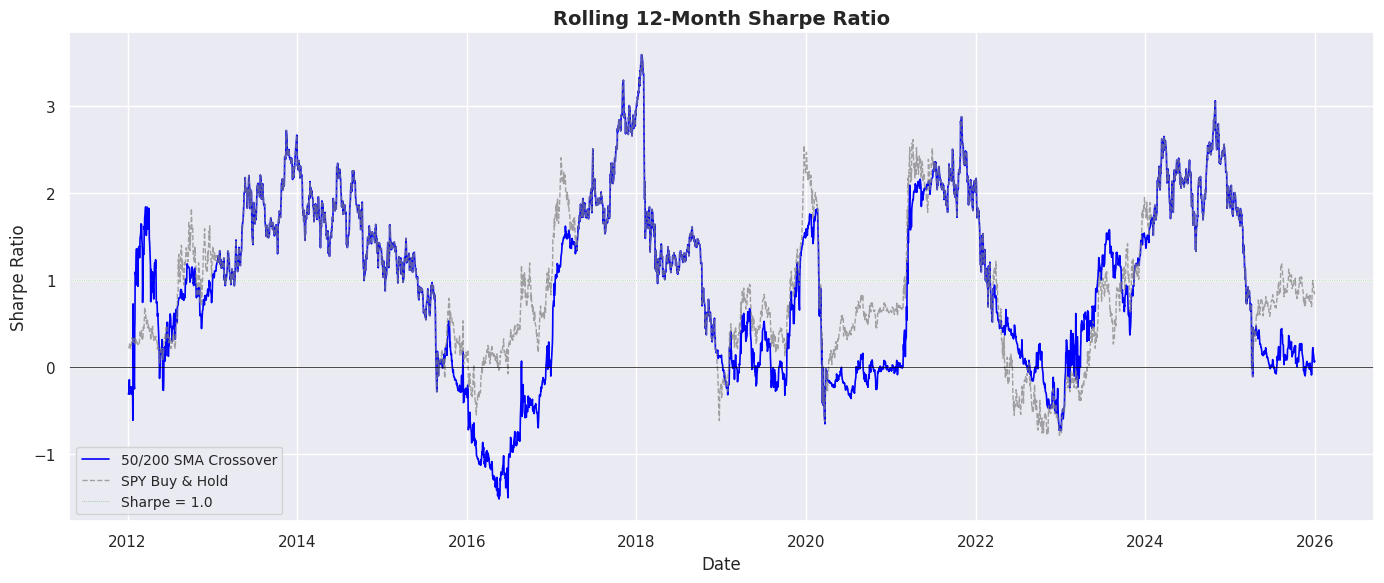

In [20]:
# --- Rolling 12-Month Sharpe Ratio ---
# The summary table gives us the Sharpe for the full 15-year period.
# But a single number hides how performance varied over time.
# A strategy might have a decent overall Sharpe because one great year
# pulled up the average, while the rest of the period was mediocre.
#
# The rolling Sharpe calculates the Sharpe ratio using only the
# trailing 252 trading days (approximately one year) at each point.
# This shows periods of strength and weakness that the full-period
# number cannot reveal.
#
# We calculate it the same way as the full-period Sharpe:
#   rolling mean of daily returns * 252 (annualized return)
#   divided by
#   rolling std of daily returns * sqrt(252) (annualized volatility)

rolling_window = 252  # approximately one year of trading days

# Rolling annualized return (numerator)
strategy_rolling_return = strategy_returns.rolling(rolling_window).mean() * 252
benchmark_rolling_return = benchmark_returns.rolling(rolling_window).mean() * 252

# Rolling annualized volatility (denominator)
strategy_rolling_vol = strategy_returns.rolling(rolling_window).std() * np.sqrt(252)
benchmark_rolling_vol = benchmark_returns.rolling(rolling_window).std() * np.sqrt(252)

# Rolling Sharpe ratio
strategy_rolling_sharpe = strategy_rolling_return / strategy_rolling_vol
benchmark_rolling_sharpe = benchmark_rolling_return / benchmark_rolling_vol

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(strategy_rolling_sharpe, color='blue', linewidth=1.2,
        label='50/200 SMA Crossover')
ax.plot(benchmark_rolling_sharpe, color='gray', linewidth=1,
        linestyle='--', alpha=0.7, label='SPY Buy & Hold')

# Reference lines
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axhline(y=1, color='green', linewidth=0.5, linestyle=':',
           alpha=0.5, label='Sharpe = 1.0')

ax.set_title('Rolling 12-Month Sharpe Ratio', fontsize=14, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.set_xlabel('Date')
ax.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()

The rolling Sharpe chart reveals something the summary table hides: both strategies spend most of their time far from their long-run average. The Sharpe ratio swings between -1 and 3.5 depending on which 12-month window you are looking at. The full-period Sharpes of 0.694 and 0.808 are averages of wildly different experiences.

A few patterns stand out.

The two lines move together most of the time. This makes sense: when the crossover signal is long SPY (79% of days), the strategy is SPY. The lines only diverge meaningfully when the crossover moves to cash, which creates the brief periods where the blue line separates from the gray.

Look at late 2017 into early 2018: the crossover's rolling Sharpe spiked above 3.5, well above SPY's. This was a period of steady gains with low volatility where the crossover happened to be fully invested. But that same strategy then cratered into negative territory in late 2018 as it whipsawed in and out of SPY during the fourth-quarter selloff. One year you look like a genius, the next you look like a fool. Same strategy, same parameters.

The post-COVID period from 2020 to 2021 is another revealing stretch. SPY's rolling Sharpe recovered sharply as the market rallied, while the crossover lagged because it was still in cash during the early stages of the rebound. The crossover eventually caught up, but months later.

This is why a single Sharpe ratio for a full backtest period can be misleading. It smooths over years of underperformance and outperformance into one number. The rolling view shows you the experience of actually living with the strategy, and that experience is far more volatile than the summary statistic suggests. Any time someone quotes you a Sharpe ratio, your first question should be: what did the rolling Sharpe look like along the way?


### 8.2 Rolling 3-Year Returns

The rolling Sharpe ratio shows us how risk-adjusted performance varied over time. Rolling returns answer a different question: what did investors with different starting dates actually earn?

For 3-year rolling returns, we compute the annualized return over every 36-month window in the sample. With 15 years of monthly data, this gives us 144 distinct 3-year periods, each one representing a different starting month. Together they form a distribution of investor experiences rather than a single point estimate.

Three-year rolling returns are my preferred evaluation tool for any strategy I am seriously considering. Three years is long enough to span multiple market environments without collapsing the sample size. The two questions I want answered are: in what percentage of rolling 3-year periods did the strategy beat its benchmark, and what was the worst rolling 3-year period? I want the percentage above 60% and the worst period to be no worse than the benchmark's worst period over the same window. If either condition fails, the strategy is not worth deploying regardless of what its full-period Sharpe says.

In [24]:
# --- Rolling returns calculation ---
# We work in monthly returns rather than daily because rolling 36-month
# windows are the standard practitioner convention, and monthly data is
# less noisy for this kind of analysis. We already have the monthly
# returns from Section 6 (the resample to month-end).

def calculate_rolling_returns(df_returns, window):
    """
    Calculate annualized rolling returns over a fixed window.

    Parameters:
    -----------
    df_returns : pd.DataFrame
        Monthly returns in decimal form. Each column is one strategy.
    window : int
        Rolling window size in months (36 for 3-year rolling returns)

    Returns:
    --------
    pd.DataFrame : annualized rolling returns for each column.
                   First (window - 1) rows will be NaN.
    """
    # Compound the returns within each rolling window:
    #   product of (1 + r) gives total return for the window
    #   minus 1 converts back from growth factor to return
    # Then annualize by raising to the power of (12 / window months)
    rolling_total = df_returns.rolling(window=window).apply(
        lambda x: np.prod(1 + x) - 1, raw=False
    )
    rolling_annualized = (1 + rolling_total) ** (12 / window) - 1
    return rolling_annualized


def rolling_return_stats(rolling_returns, benchmark_col):
    """
    Calculate key statistics for rolling returns vs a benchmark.

    Parameters:
    -----------
    rolling_returns : pd.DataFrame
        Rolling returns from calculate_rolling_returns()
    benchmark_col : str
        Column name of the benchmark to compare against

    Returns:
    --------
    pd.DataFrame : statistics including the percentage of periods
                   where each column beat the benchmark, plus the
                   maximum and minimum rolling returns observed.
    """
    # Drop the warmup NaN rows so the comparison is clean
    rr = rolling_returns.dropna()

    df_stats = pd.DataFrame()
    for col in rr.columns:
        # Percentage of rolling periods where this column beat the benchmark
        # Above 60% is my threshold for a strategy worth deploying
        pct_greater = (rr[col] > rr[benchmark_col]).sum() / len(rr) * 100
        df_stats.loc[col, '% Periods Greater Than Benchmark'] = round(pct_greater, 1)

    # Best and worst rolling periods, expressed as percentages
    df_stats['Best Rolling Period (%)'] = (rr.max() * 100).round(2)
    df_stats['Worst Rolling Period (%)'] = (rr.min() * 100).round(2)

    return df_stats


# --- Build the monthly returns DataFrame for both strategies ---
df_monthly = pd.DataFrame({
    'SMA_Crossover': strategy_monthly,
    'SPY_Buy_Hold': benchmark_monthly,
})

# --- Calculate rolling 3-year (36-month) returns ---
window_months = 36
rolling_3yr = calculate_rolling_returns(df_monthly, window=window_months)

# --- Calculate the comparison statistics ---
stats_3yr = rolling_return_stats(rolling_3yr, benchmark_col='SPY_Buy_Hold')

print(f"Rolling {window_months}-month annualized returns")
print("=" * 65)
print(f"Total rolling periods: {rolling_3yr.dropna().shape[0]}")
print()
print(stats_3yr.to_string())

Rolling 36-month annualized returns
Total rolling periods: 145

               % Periods Greater Than Benchmark  Best Rolling Period (%)  Worst Rolling Period (%)
SMA_Crossover                           17.9000                  19.5300                    0.7600
SPY_Buy_Hold                             0.0000                  25.9700                    5.0400


The crossover strategy beat SPY in only 17.9% of rolling 3-year periods. My threshold for a strategy worth deploying was 60%. The crossover did not just fail this test, it failed catastrophically. An investor picking a random month between 2011 and 2022 to start the strategy and holding it for three years had less than a one-in-five chance of beating buy-and-hold over that window.

The best and worst columns reinforce the verdict. The crossover's best 3-year period earned 19.5% annualized, while SPY's best earned 25.97%. The crossover's worst earned 0.76% annualized, while SPY's worst still earned 5.04%. The crossover loses on both ends of the distribution: it never quite matched SPY's best stretches, and even its best stretches were worse than SPY's worst stretches. There is no scenario in this 15-year sample where the crossover strategy delivered a meaningfully better experience than buy-and-hold.

This is why I run rolling returns analysis on every strategy I evaluate. A trailing 15-year Sharpe of 0.694 might look like a strategy that is competitive with buy-and-hold but slightly worse. The rolling 3-year analysis tells you that no investor in this sample, regardless of when they started, came close to outperforming. The conclusions agree, but the rolling view makes the magnitude of the failure undeniable.

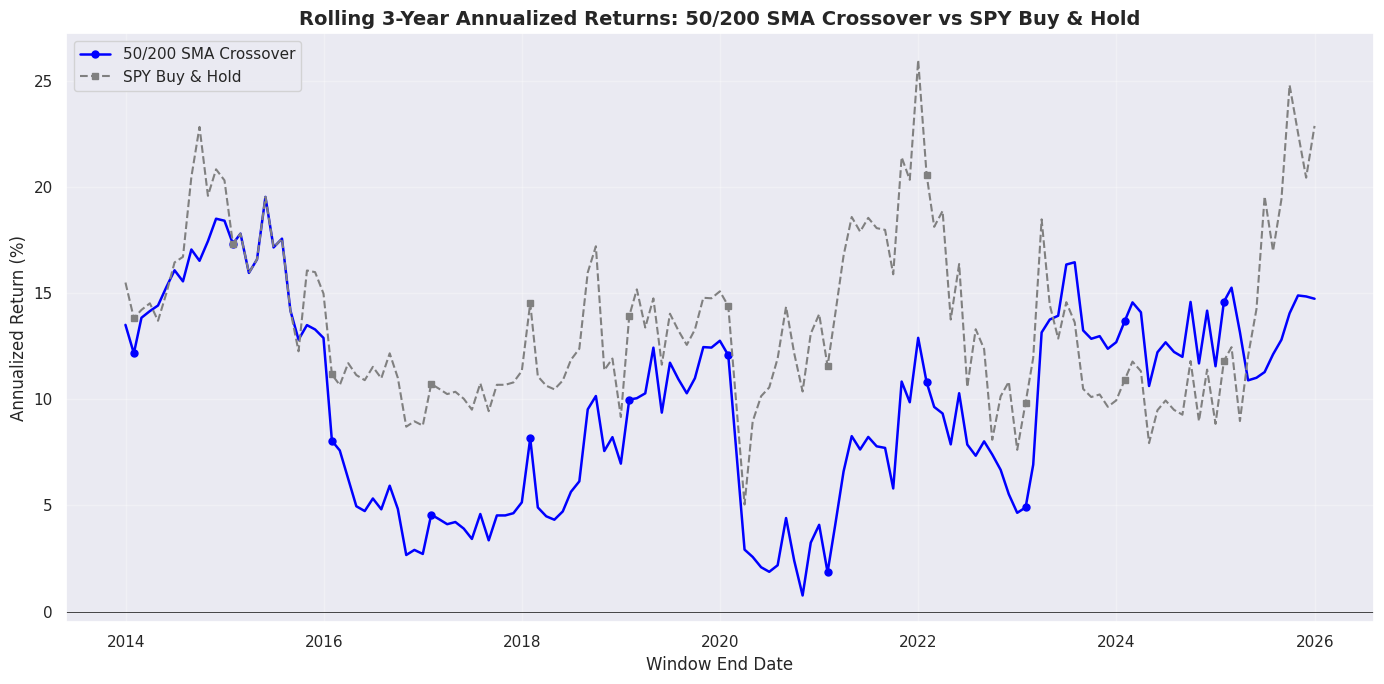

In [25]:
# --- Plot rolling 3-year returns over time ---
# Print-friendly styling: distinct line styles plus markers at intervals
# so the two series are distinguishable in grayscale.
# Markers spaced every 12 months of the rolling series.

fig, ax = plt.subplots(figsize=(14, 7))

# Strategy: solid line with circle markers
ax.plot(rolling_3yr.index, rolling_3yr['SMA_Crossover'] * 100,
        color='blue', linewidth=1.8,
        linestyle='-', marker='o', markevery=12, markersize=5,
        label='50/200 SMA Crossover')

# Benchmark: dashed line with square markers
ax.plot(rolling_3yr.index, rolling_3yr['SPY_Buy_Hold'] * 100,
        color='gray', linewidth=1.5,
        linestyle='--', marker='s', markevery=12, markersize=5,
        label='SPY Buy & Hold')

# Reference line at zero so readers can see when either strategy
# was actually losing money over a 3-year window
ax.axhline(y=0, color='black', linewidth=0.5)

ax.set_title('Rolling 3-Year Annualized Returns: '
             '50/200 SMA Crossover vs SPY Buy & Hold',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Annualized Return (%)')
ax.set_xlabel('Window End Date')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart makes the verdict visual. The two lines start in lockstep through 2014 and into early 2015 because the strategy was long SPY for almost that entire window. They diverge sharply in late 2015 when the crossover signal moved to cash and missed a portion of the subsequent recovery. The crossover line stays consistently below the SPY line for almost the entire remaining period, with only brief moments where the gap closes.

Notice the depth of the gap during certain windows. Around the 3-year window ending in late 2020 and early 2021, SPY's rolling return touched 20% annualized while the crossover sat near 1%. That window captured the full COVID rally that the crossover missed because it was sitting in cash during the early stages of the recovery. The window ending in early 2022 shows another sharp divergence: SPY rolling at 23% annualized, the crossover at 11%. The gaps are not subtle.

Both lines stay above zero across the entire sample, which means there was no rolling 3-year window where either strategy actually lost money. That is not a property of the strategies. It is a property of this 15-year window, which was overwhelmingly bullish for US equities. A more challenging sample period (one that included the 2008 crisis or a prolonged bear market) would likely show different rolling performance for both lines, and possibly a different verdict on the crossover. Always evaluate strategies across as many market environments as your data allows.

## Wrapping Up

This notebook covered the core toolkit for evaluating any investment strategy from the ground up. We built every major performance metric as code: return measures, multiple flavors of risk, the most useful risk-adjusted ratios, trading metrics, and rolling analysis across both Sharpe ratios and 3-year returns. We then consolidated them into a single reusable function that you can apply to any strategy you build for the rest of this book and beyond.

Working through the metrics manually serves a purpose beyond just learning the math. Every number we calculated has assumptions baked into it: the annualization factor, the risk-free rate, the choice of monthly vs daily data, the formula used for downside deviation. When you write the code yourself, those assumptions are explicit. You know exactly what each number represents because you decided what it would represent.

The 50/200 SMA crossover strategy served as our test case throughout. The verdict was clear and consistent across every metric we built: the strategy underperformed SPY buy-and-hold on absolute return, on every risk-adjusted ratio, and in 82% of rolling 3-year windows. The maximum drawdown was identical because both strategies experienced the COVID crash equally. The strategy provided no meaningful protection in exchange for its return drag. This is a useful negative result. The 50/200 crossover is one of the most popular signals in retail trading literature, and a careful evaluation shows it does not add value relative to simply holding the index.

In *Notebook 7.2*, we cover the same evaluation problem from a different angle. Instead of building everything from scratch, we use two professional Python packages: PyFolio and QuantStats. We will see what each package produces, where they agree, where they quietly disagree with each other and with our manual calculations, and where you still need to write your own code. The manual toolkit we built here is the reference you will use to verify and customize the package output.